In [2]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

print(tf.__version__)

/Users/abbylaber/Documents/GitHub/pneumonia-mad2502-project/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


2.20.0


In [3]:
BASE_DIR = "data/chest_xray"

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "val")
TEST_DIR  = os.path.join(BASE_DIR, "test")

for split, path in [("Train", TRAIN_DIR), ("Val", VAL_DIR), ("Test", TEST_DIR)]:
    for label in ["NORMAL", "PNEUMONIA"]:
        count = len(os.listdir(os.path.join(path, label)))
        print(f"{split} | {label}: {count} images")

Train | NORMAL: 1341 images
Train | PNEUMONIA: 3875 images
Val | NORMAL: 8 images
Val | PNEUMONIA: 8 images
Test | NORMAL: 234 images
Test | PNEUMONIA: 390 images


In [4]:
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [5]:
train_filenames = tf.io.gfile.glob(os.path.join(TRAIN_DIR, "*", "*"))
val_filenames = tf.io.gfile.glob(os.path.join(VAL_DIR, "*", "*"))

filenames = train_filenames + val_filenames
train_filenames, val_filenames = train_test_split(filenames, test_size = 0.2, random_state = 42)

COUNT_NORMAL = len([f for f in train_filenames if "NORMAL" in f])
COUNT_PNEUMONIA = len([f for f in train_filenames if "PNEUMONIA" in f])
print("Normal images count in training set:", COUNT_NORMAL)
print("Pneumonia images count in training set:", COUNT_PNEUMONIA)

train_list_ds = tf.data.Dataset.from_tensor_slices(train_filenames)
val_list_ds = tf.data.Dataset.from_tensor_slices(val_filenames)

TRAIN_IMG_COUNT = tf.data.experimental.cardinality(train_list_ds).numpy()
VAL_IMG_COUNT = tf.data.experimental.cardinality(val_list_ds).numpy()
print("Training images count:", TRAIN_IMG_COUNT)
print("Validating images count:", VAL_IMG_COUNT)

CLASS_NAMES = np.array([os.path.basename(p) for p in tf.io.gfile.glob(os.path.join(TRAIN_DIR, "*"))])
print(CLASS_NAMES)


Normal images count in training set: 1059
Pneumonia images count in training set: 3126
Training images count: 4185
Validating images count: 1047
['PNEUMONIA' 'NORMAL']


In [6]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
IMAGE_SIZE = [180, 180]   # matches source
BATCH_SIZE = 16           # matches source

def get_label(file_path):
    parts = tf.strings.split(file_path, os.path.sep)
    return parts[-2] == "PNEUMONIA"

def decode_img(img):
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return tf.image.resize(img, IMAGE_SIZE)

def process_path(file_path):
    label = get_label(file_path)
    label = tf.cast(label, tf.float32)
    img = tf.io.read_file(file_path)
    img = decode_img(img)
    return img, label

train_ds = train_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
val_ds   = val_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)

2026-04-01 18:09:45.280717: W tensorflow/core/kernels/data/cache_dataset_ops.cc:917] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


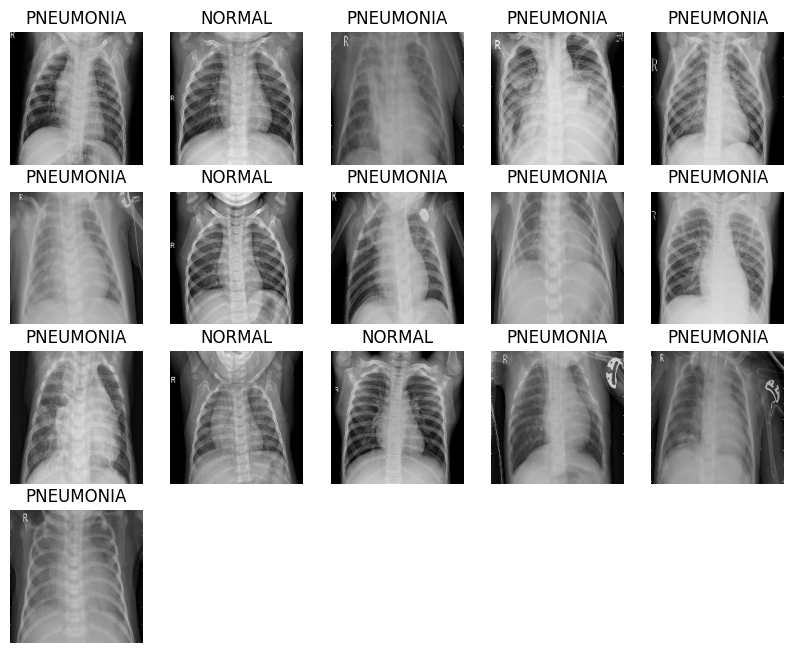

In [7]:
def prepare_for_training(ds, cache=True, shuffle_buffer_size=1000):
    if cache:
        ds = ds.cache() if cache is True else ds.cache(cache)
    ds = ds.shuffle(buffer_size=shuffle_buffer_size)
    ds = ds.repeat()
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(buffer_size=AUTOTUNE)
    return ds

train_ds = prepare_for_training(train_ds)
val_ds   = prepare_for_training(val_ds)

image_batch, label_batch = next(iter(train_ds))
image_batch = image_batch.numpy()
label_batch = label_batch.numpy()

def show_batch(image_batch, label_batch):
    plt.figure(figsize = (10,10))
    n_show = min(25, image_batch.shape[0])
    for n in range(n_show):
        ax = plt.subplot(5,5,n+1)
        plt.imshow(image_batch[n])
        plt.title("PNEUMONIA" if label_batch[n] > 0.5 else "NORMAL")
        plt.axis("off")

show_batch(image_batch, label_batch)


In [8]:
def conv_block(filters):
    block = tf.keras.Sequential([
        tf.keras.layers.SeparableConv2D(filters, 3, activation='relu', padding='same'),
        tf.keras.layers.SeparableConv2D(filters, 3, activation='relu', padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.MaxPool2D()
    ])
    return block

def dense_block(units, dropout_rate):
    block = tf.keras.Sequential([
        tf.keras.layers.Dense(units, activation='relu'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Dropout(dropout_rate)
    ])
    return block

def build_model():
    model = tf.keras.Sequential([
        tf.keras.Input(shape=(IMAGE_SIZE[0], IMAGE_SIZE[1], 3)),

        tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
        tf.keras.layers.Conv2D(16, 3, activation='relu', padding='same'),
        tf.keras.layers.MaxPool2D(),

        conv_block(32),
        conv_block(64),

        conv_block(128),
        tf.keras.layers.Dropout(0.2),

        conv_block(256),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Flatten(),
        dense_block(512, 0.7),
        dense_block(128, 0.5),
        dense_block(64, 0.3),

        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model

In [9]:
initial_bias = np.log([COUNT_PNEUMONIA / COUNT_NORMAL])
weight_for_0 = (1 / COUNT_NORMAL) * (TRAIN_IMG_COUNT) / 2.0
weight_for_1 = (1 / COUNT_PNEUMONIA) * (TRAIN_IMG_COUNT) / 2.0

class_weight = {0: weight_for_0, 1: weight_for_1}
print("Weight for class 0:", weight_for_0)
print("Weight for class 1:", weight_for_1)

model = build_model()

METRICS = [
    'accuracy',
    tf.keras.metrics.Precision(name='precision'),
    tf.keras.metrics.Recall(name='recall')
]

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=METRICS
)

Weight for class 0: 1.9759206798866857
Weight for class 1: 0.6693857965451055


In [10]:
EPOCHS = 25

history = model.fit(
    train_ds,
    steps_per_epoch=TRAIN_IMG_COUNT // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_ds,
    validation_steps=VAL_IMG_COUNT // BATCH_SIZE,
    class_weight=class_weight
)

Epoch 1/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 43s 148ms/step - accuracy: 0.7386 - loss: 0.4896 - precision: 0.9188 - recall: 0.7070 - val_accuracy: 0.7221 - val_loss: 0.7484 - val_precision: 0.7221 - val_recall: 1.0000
Epoch 2/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 32s 124ms/step - accuracy: 0.8987 - loss: 0.2510 - precision: 0.9744 - recall: 0.8865 - val_accuracy: 0.7231 - val_loss: 1.4283 - val_precision: 0.7231 - val_recall: 1.0000
Epoch 3/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 32s 122ms/step - accuracy: 0.9205 - loss: 0.2018 - precision: 0.9773 - recall: 0.9134 - val_accuracy: 0.8865 - val_loss: 0.2455 - val_precision: 0.8642 - val_recall: 1.0000
Epoch 4/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 41s 158ms/step - accuracy: 0.9344 - loss: 0.1749 - precision: 0.9793 - recall: 0.9323 - val_accuracy: 0.9712 - val_loss: 0.0867 - val_precision: 0.9750 - val_recall: 0.9854
Epoch 5/25
261/261 ━━━━━━━━━━━━━━━━━━━━ 31s 120ms/step - accuracy: 0.9400 - loss: 0.1541 - precision: 0.9834 - recall: 0.9364 - val_accuracy: 0.9433

In [11]:
test_list_ds = tf.data.Dataset.list_files(os.path.join(TEST_DIR, "*", "*"))
TEST_IMAGE_COUNT = tf.data.experimental.cardinality(test_list_ds).numpy()

test_ds = test_list_ds.map(process_path, num_parallel_calls=AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)

loss, acc, prec, rec = model.evaluate(test_ds)
print("Test accuracy:", acc)
print("Test precision:", prec)
print("Test recall:", rec)

39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.8003 - loss: 0.8555 - precision: 0.7578 - recall: 0.9964
Test accuracy: 0.8044871687889099
Test precision: 0.7648221254348755
Test recall: 0.9923076629638672
